# Week 3 – Modeling (Boosting) & MLflow Experiment Tracking
## Fake News Detection Project

**Goal:**
- Train multiple boosting classifiers (XGBoost, LightGBM, LogisticRegression baseline)
- Track all experiments with MLflow
- Select the best model and save it for the API

In [1]:
import mlflow

mlflow.set_tracking_uri("http://localhost:5000")

In [2]:
# Imports
import numpy as np
import pandas as pd
import scipy.sparse as sp
import pickle
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score, recall_score
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


print('Libraries loaded ✅')

Libraries loaded ✅


In [3]:
import pandas as pd
import pickle
import json
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack, csr_matrix
import numpy as np
import sys, os
sys.path.insert(0, '..')
from src.preprocess import load_and_prepare

# ─── Recharge tout depuis les CSVs bruts ───
X_train, X_test, y_train, y_test, tfidf, feature_cols, subject_enc, df = load_and_prepare(
    data_dir='../data',
    test_size=0.2,
    random_state=42
)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts()}")
print(f"feature_cols: {feature_cols}")
print("✅ Données rechargées depuis True.csv + Fake.csv")

X_train : (35918, 50007)
X_test  : (8980, 50007)
y_train distribution:
label
0    18785
1    17133
Name: count, dtype: int64
feature_cols: ['num_exclamations', 'num_questions', 'uppercase_ratio', 'avg_word_len', 'text_word_count', 'title_word_count', 'unique_word_ratio']
✅ Données rechargées depuis True.csv + Fake.csv


In [4]:
import re

with open('../src/preprocess.py', 'r') as f:
    content = f.read()

# Fix signature
content = content.replace(
    'def load_and_prepare(data_dir: str, test_size: float = 0.2, random_state: int = 42,\n                     tfidf_kwargs: Optional[dict] = None):',
    'def load_and_prepare(data_dir: str, test_size: float = 0.2, random_state: int = 42,\n                     tfidf_kwargs: Optional[dict] = None, include_subject: bool = False):'
)

# Fix build_feature_matrix calls
content = content.replace(
    'X_train, tfidf, feature_cols, subject_enc = build_feature_matrix(\n        train_df, fit=True, tfidf_kwargs=tfidf_kwargs\n    )',
    'X_train, tfidf, feature_cols, subject_enc = build_feature_matrix(\n        train_df, fit=True, tfidf_kwargs=tfidf_kwargs, include_subject=include_subject\n    )'
)
content = content.replace(
    'X_test,  _,     _,            _           = build_feature_matrix(\n        test_df, tfidf=tfidf, subject_encoder=subject_enc, fit=False\n    )',
    'X_test,  _,     _,            _           = build_feature_matrix(\n        test_df, tfidf=tfidf, subject_encoder=subject_enc, fit=False, include_subject=include_subject\n    )'
)

with open('../src/preprocess.py', 'w') as f:
    f.write(content)

print("Done!")

Done!


In [5]:
import sys
sys.path.insert(0, '..')
from src.preprocess import load_and_prepare

X_train, X_test, y_train, y_test, tfidf, feature_cols, subject_enc, df = load_and_prepare(
    data_dir='../data',
    test_size=0.2,
    random_state=42,
    include_subject=False  # ← ajoute juste ça
)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train :\n{y_train.value_counts()}")

X_train : (35918, 50007)
X_test  : (8980, 50007)
y_train :
label
0    18785
1    17133
Name: count, dtype: int64


In [6]:
# ─────────────────────────────────────────
# MLflow Setup
# ─────────────────────────────────────────
mlflow.set_tracking_uri('http://localhost:5000')   # or 'sqlite:///mlflow.db'
mlflow.set_experiment('fake_news_detection')

def evaluate(y_true, y_pred, y_proba=None):
    """Return a dict of evaluation metrics."""
    metrics = {
        'accuracy' : accuracy_score(y_true, y_pred),
        'f1'       : f1_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall'   : recall_score(y_true, y_pred),
    }
    if y_proba is not None:
        metrics['roc_auc'] = roc_auc_score(y_true, y_proba)
    return metrics

print('MLflow configured ✅')

2026/03/08 21:37:07 INFO mlflow.tracking.fluent: Experiment with name 'fake_news_detection' does not exist. Creating a new experiment.


MLflow configured ✅


In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate(y_true, y_pred, y_proba):
    return {
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall'   : recall_score(y_true, y_pred),
        'f1'       : f1_score(y_true, y_pred),
        'roc_auc'  : roc_auc_score(y_true, y_proba),
    }

In [8]:
# ─────────────────────────────────────────
# Model 1: Logistic Regression (Baseline)
# ─────────────────────────────────────────
import tempfile
import os
import mlflow.sklearn

lr_params = {'C': 1.0, 'max_iter': 500, 'solver': 'saga', 'random_state': 42}

with mlflow.start_run(run_name='LogisticRegression_baseline'):
    mlflow.log_params(lr_params)
    
    lr = LogisticRegression(**lr_params)
    lr.fit(X_train, y_train)
    
    y_pred  = lr.predict(X_test)
    y_proba = lr.predict_proba(X_test)[:, 1]
    metrics = evaluate(y_test, y_pred, y_proba)
    
    mlflow.log_metrics(metrics)

    with tempfile.TemporaryDirectory() as tmp:
        path = os.path.join(tmp, "model")
        mlflow.sklearn.save_model(lr, path)
        mlflow.log_artifacts(path, artifact_path="model")
    
    print('Logistic Regression:')
    for k, v in metrics.items():
        print(f'  {k:10}: {v:.4f}')

2026/03/08 21:38:15 INFO mlflow.tracking._tracking_service.client: 🏃 View run LogisticRegression_baseline at: http://localhost:5000/#/experiments/389634077438095641/runs/7f9be79cca2c4f168bd5ae40cb127f9a.
2026/03/08 21:38:15 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://localhost:5000/#/experiments/389634077438095641.


Logistic Regression:
  accuracy  : 0.7595
  precision : 0.8549
  recall    : 0.5971
  f1        : 0.7031
  roc_auc   : 0.8940


In [9]:
# ─────────────────────────────────────────
# Model 2: XGBoost
# ─────────────────────────────────────────
xgb_params = {
    'n_estimators'        : 500,
    'max_depth'           : 5,
    'learning_rate'       : 0.1,
    'subsample'           : 0.8,
    'colsample_bytree'    : 0.8,
    'eval_metric'         : 'logloss',
    'early_stopping_rounds': 20,  # ✅ Déplacé ici
    'random_state'        : 42,
    'tree_method'         : 'hist',
    'n_jobs'              : -1
}

with mlflow.start_run(run_name='XGBoost'):
    mlflow.log_params(xgb_params)

    xgb = XGBClassifier(**xgb_params)
    xgb.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=50
        # ❌ early_stopping_rounds retiré d'ici
    )

    y_pred  = xgb.predict(X_test)
    y_proba = xgb.predict_proba(X_test)[:, 1]

    metrics = evaluate(y_test, y_pred, y_proba)
    mlflow.log_metrics(metrics)

    mlflow.log_metric("best_iteration", xgb.best_iteration)
    mlflow.log_metric("best_score", xgb.best_score)

    mlflow.xgboost.log_model(xgb, "model")

[0]	validation_0-logloss:0.61551
[50]	validation_0-logloss:0.06036
[100]	validation_0-logloss:0.03085
[150]	validation_0-logloss:0.02182
[200]	validation_0-logloss:0.01742
[250]	validation_0-logloss:0.01528
[300]	validation_0-logloss:0.01403
[350]	validation_0-logloss:0.01318
[400]	validation_0-logloss:0.01234
[450]	validation_0-logloss:0.01214
[457]	validation_0-logloss:0.01209


2026/03/08 22:04:04 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/03/08 22:04:05 INFO mlflow.tracking._tracking_service.client: 🏃 View run XGBoost at: http://localhost:5000/#/experiments/389634077438095641/runs/c9e360c39637468c8fb7f8cbf7299fca.
2026/03/08 22:04:05 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://localhost:5000/#/experiments/389634077438095641.


In [10]:
# ─────────────────────────────────────────
# Model 3: LightGBM (Best expected)
# ─────────────────────────────────────────
import lightgbm as lgb
from lightgbm import LGBMClassifier

lgbm_params = {
    "n_estimators": 300,
    "learning_rate": 0.1,
    "num_leaves": 31,
    "objective": "binary",
    "n_jobs": -1
}

with mlflow.start_run(run_name="LightGBM"):
    mlflow.log_params(lgbm_params)
    
    lgbm = LGBMClassifier(**lgbm_params)
    
    lgbm.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric="binary_logloss",
        callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(0)]
    )
    
    y_pred  = lgbm.predict(X_test)
    y_proba = lgbm.predict_proba(X_test)[:, 1]

    metrics = evaluate(y_test, y_pred, y_proba)
    mlflow.log_metrics(metrics)
    mlflow.sklearn.log_model(lgbm, "model")

[LightGBM] [Info] Number of positive: 17133, number of negative: 18785
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 4.011768 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2779871
[LightGBM] [Info] Number of data points in the train set: 35918, number of used features: 49759
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.477003 -> initscore=-0.092052
[LightGBM] [Info] Start training from score -0.092052
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[246]	valid_0's binary_logloss: 0.0117685


2026/03/08 22:07:54 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/03/08 22:07:55 INFO mlflow.tracking._tracking_service.client: 🏃 View run LightGBM at: http://localhost:5000/#/experiments/389634077438095641/runs/3d399be282bd406bbcf0bc536e78956e.
2026/03/08 22:07:55 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://localhost:5000/#/experiments/389634077438095641.


Classification Report (LightGBM):
              precision    recall  f1-score   support

        Fake       1.00      0.99      1.00      4696
        Real       0.99      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



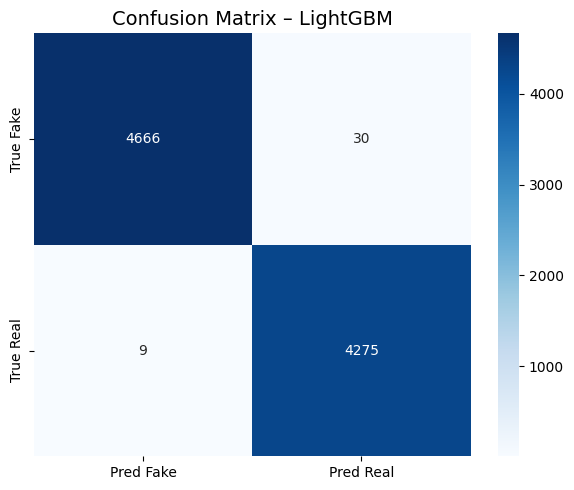

In [11]:
# ─────────────────────────────────────────
# Best Model: Confusion Matrix & Report
# ─────────────────────────────────────────
# We'll use LightGBM as final model
best_model = lgbm

y_pred_final  = best_model.predict(X_test)
y_proba_final = best_model.predict_proba(X_test)[:, 1]

print('Classification Report (LightGBM):')
print(classification_report(y_test, y_pred_final, target_names=['Fake', 'Real']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Fake', 'Pred Real'],
            yticklabels=['True Fake', 'True Real'])
plt.title('Confusion Matrix – LightGBM', fontsize=14)
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png', dpi=150)
plt.show()

In [12]:
# ─── Save ALL artifacts (modèle + vectorizer + feature_cols) ───
import pickle, json

with open('../data/best_model.pkl', 'wb') as f:
    pickle.dump(lgbm, f)

with open('../data/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

with open('../data/feature_cols.json', 'w') as f:
    json.dump(list(feature_cols), f)

if subject_enc is not None:
    with open('../data/subject_encoder.pkl', 'wb') as f:
        pickle.dump(subject_enc, f)

print("Type sauvegardé:", type(lgbm))
print("✅ Tous les artifacts sauvegardés correctement !")

Type sauvegardé: <class 'lightgbm.sklearn.LGBMClassifier'>
✅ Tous les artifacts sauvegardés correctement !


In [13]:
with open('../data/best_model.pkl', 'wb') as f:
    pickle.dump(lgbm, f)

with open('../data/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

with open('../data/feature_cols.json', 'w') as f:
    json.dump(list(feature_cols), f)

if subject_enc:
    with open('../data/subject_encoder.pkl', 'wb') as f:
        pickle.dump(subject_enc, f)

print("✅ Tout sauvegardé !")

✅ Tout sauvegardé !


In [14]:
from sklearn.metrics import accuracy_score, classification_report
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      4696
           1       0.99      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



In [15]:
real_article = df[df['label']==1].iloc[0]
print("TITLE:", real_article['title'])
print("TEXT:", real_article['text'][:300])

TITLE: California AG pledges to defend birth control insurance coverage
TEXT: California Attorney General Xavier Becerra said on Friday he was “prepared to take whatever action it takes” to defend the Obamacare mandate that health insurers provide birth control, now that the Trump administration has moved to circumvent it. The administration’s new contraception exemptions “ar


In [16]:
with open('../src/preprocess.py', 'r') as f:
    content = f.read()

content = content.replace(
    '    df = (\n        pd.concat([true_df, fake_df], ignore_index=True)\n        .sample(frac=1, random_state=random_state)\n        .reset_index(drop=True)\n    )',
    '    df = (\n        pd.concat([true_df, fake_df], ignore_index=True)\n        .sample(frac=1, random_state=random_state)\n        .reset_index(drop=True)\n    )\n    # Remove Reuters dateline to avoid data leakage\n    df["text"] = df["text"].str.replace(r\'^[A-Z\\s]+\\([^)]+\\)\\s*-\\s*\', \'\', regex=True)'
)

with open('../src/preprocess.py', 'w') as f:
    f.write(content)

print("Done!")


Done!


In [17]:
with open('../src/preprocess.py', 'r') as f:
    content = f.read()

content = content.replace(
    '    )\n    # Remove Reuters dateline to avoid data leakage\n    df["text"] = df["text"].str.replace(r\'^[A-Z\\s]+\\([^)]+\\)\\s*-\\s*\', \'\', regex=True)',
    '    )'
)

with open('../src/preprocess.py', 'w') as f:
    f.write(content)

print("Done!")

Done!
